# تحليل سوق الوظائف وتأثير الذكاء الاصطناعي (Global AI Job Market Dataset)

**المشروع المرجعي من البي دي اف:** Project Idea 3 — Human Resources Dataset Analysis

البيانات دي عبارة عن 5000 إعلان وظيفة من سنة 2010 لحد 2025، وفيها بيانات عن الراتب،
مستوى الأقدمية، الصناعة، المنطقة الجغرافية، مدى ذكر الذكاء الاصطناعي في الوظيفة،
درجة "AI Intensity"، درجة مخاطر الأتمتة (automation risk)، ومستوى مخاطر الإحلال الوظيفي
بسبب الذكاء الاصطناعي (Low / Medium / High).

المصدر: ملف `data/Excel_Final_Project_5.xlsx` — شيت `Raw Data`.

هنطبق نفس خطة الأسابيع الأربعة الموجودة في البي دي اف:
1. **Week 1** — بناء Data Model وتنظيف البيانات (SQL + pandas)
2. **Week 2** — أسئلة تحليلية (Analysis Questions)
3. **Week 3** — أسئلة تنبؤية (Forecasting Questions) باستخدام scikit-learn
4. **Week 4** — Dashboard تفاعلي (اتعمل بـ Streamlit بدل Tableau — ملف منفصل `dashboard/app.py`)

In [4]:
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

RAW_XLSX = "data/Excel_Final_Project_5.xlsx"
DB_PATH = "data/processed/job_market_model.db"
CLEAN_CSV = "data/processed/cleaned_job_postings.csv"
FIG_DIR = "outputs/figures"

## Week 1 — Data Cleaning & Preprocessing

### 1.1 تحميل البيانات الخام

In [27]:
df = pd.read_excel(RAW_XLSX, sheet_name="Raw Data ")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 5000 rows x 39 columns


,job_id,posting_year,country,region,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,...,Core_Software Engineering,Core_Statistics,AI_LLMs,AI_MLOps,AI_NLP,AI_computer vision,AI_deep learning,AI_generative AI,AI_machine learning,AI_reinforcement learning
0,87e6f4f5-16ce-4479-9ce4-6d3973e37e11,2010,Indonesia,Southeast Asia,Future Analytics,Enterprise,Energy,Product Manager,Junior,False,...,True,True,False,False,False,False,False,False,False,False
1,c41a9305-8dd1-4716-8953-2be6a0f256d7,2010,Italy,Europe,Prime Systems,Small,Agriculture,Data Scientist,Lead,False,...,True,False,False,False,False,False,False,False,False,False
2,af0a8661-6ad5-4679-9166-596671dabb4e,2010,Pakistan,South Asia,Global Solutions,Small,Manufacturing,AI Researcher,Lead,False,...,False,False,False,False,False,False,False,False,False,False
3,c14573ab-bda8-4a12-a65d-9a908b9345c1,2010,Argentina,South America,Global Technologies,Medium,Government,Policy Analyst,Junior,False,...,True,False,False,False,False,False,False,False,False,False
4,e81fff60-4d14-4bb3-b4d2-98375f1333ef,2010,Bangladesh,South Asia,NextGen Analytics,Small,Education,AI Researcher,Lead,False,...,True,True,False,False,False,False,False,False,False,False


#(EDA)


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   job_id                              5000 non-null   object 
 1   posting_year                        5000 non-null   int64  
 2   country                             5000 non-null   object 
 3   region                              5000 non-null   object 
 4   company_name                        5000 non-null   object 
 5   company_size                        5000 non-null   object 
 6   industry                            5000 non-null   object 
 7   job_title                           5000 non-null   object 
 8   seniority_level                     5000 non-null   object 
 9   ai_mentioned                        5000 non-null   bool   
 10  ai_keywords                         1623 non-null   object 
 11  ai_intensity_score                  5000 no

In [29]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

Columns with missing values:
ai_keywords    3377
ai_skills      3377
dtype: int64


In [30]:
print("Duplicate job_id:", df["job_id"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate job_id: 0
Fully duplicate rows: 0


**ملاحظات التنظيف:**
- الأعمدة `ai_keywords` و `ai_skills` فاضية بس لما `ai_mentioned = False` (يعني الوظيفة مفيهاش
  ذكر للذكاء الاصطناعي أصلًا) — ده مش خطأ في البيانات، فهنستبدلها بقيمة `"None"` بدل الحذف
  عشان منخسرش 67% من الصفوف.
- مفيش صفوف مكررة (لا بالـ job_id ولا بالكامل).
- هنتأكد إن كل الـ scores (`ai_intensity_score`, `automation_risk_score`) محصورة بين 0 و 1،
  وإن الرواتب كلها أرقام موجبة منطقية.

In [31]:
df_clean = df.copy()
df_clean["ai_keywords"] = df_clean["ai_keywords"].fillna("None")
df_clean["ai_skills"] = df_clean["ai_skills"].fillna("None")

text_cols = ["country", "region", "company_name", "company_size", "industry",
             "job_title", "seniority_level", "ai_job_displacement_risk",
             "industry_ai_adoption_stage"]
for c in text_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip()

assert df_clean["ai_intensity_score"].between(0, 1).all(), "ai_intensity_score out of [0,1] range"
assert df_clean["automation_risk_score"].between(0, 1).all(), "automation_risk_score out of [0,1] range"
assert (df_clean["salary_usd"] > 0).all(), "Found non-positive salary"

print("Missing values after cleaning:", df_clean.isna().sum().sum())
df_clean.head()

Missing values after cleaning: 0


,job_id,posting_year,country,region,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,...,Core_Software Engineering,Core_Statistics,AI_LLMs,AI_MLOps,AI_NLP,AI_computer vision,AI_deep learning,AI_generative AI,AI_machine learning,AI_reinforcement learning
0,87e6f4f5-16ce-4479-9ce4-6d3973e37e11,2010,Indonesia,Southeast Asia,Future Analytics,Enterprise,Energy,Product Manager,Junior,False,...,True,True,False,False,False,False,False,False,False,False
1,c41a9305-8dd1-4716-8953-2be6a0f256d7,2010,Italy,Europe,Prime Systems,Small,Agriculture,Data Scientist,Lead,False,...,True,False,False,False,False,False,False,False,False,False
2,af0a8661-6ad5-4679-9166-596671dabb4e,2010,Pakistan,South Asia,Global Solutions,Small,Manufacturing,AI Researcher,Lead,False,...,False,False,False,False,False,False,False,False,False,False
3,c14573ab-bda8-4a12-a65d-9a908b9345c1,2010,Argentina,South America,Global Technologies,Medium,Government,Policy Analyst,Junior,False,...,True,False,False,False,False,False,False,False,False,False
4,e81fff60-4d14-4bb3-b4d2-98375f1333ef,2010,Bangladesh,South Asia,NextGen Analytics,Small,Education,AI Researcher,Lead,False,...,True,True,False,False,False,False,False,False,False,False


### 1.3 بناء Data Model (Star Schema)

هنبني نفس فكرة الـ star schema الموجودة بالفعل في ملف الإكسيل (Fact_JobPosting + جداول Dim_*)
لكن بـ Python/SQL، وهنحملها في قاعدة بيانات SQLite عشان نقدر نستخدم استعلامات SQL حقيقية
في باقي التحليل (زي ما البي دي اف طالب: Tools: SQL, Python).

In [32]:
dim_year = (df_clean[["posting_year"]].drop_duplicates()
            .sort_values("posting_year").reset_index(drop=True))
dim_year["Year_Key"] = dim_year.index + 1

dim_geo = (df_clean[["country", "region"]].drop_duplicates()
           .sort_values(["region", "country"]).reset_index(drop=True))
dim_geo["Geo_Key"] = dim_geo.index + 1

dim_company = (df_clean[["company_name"]].drop_duplicates()
               .sort_values("company_name").reset_index(drop=True))
dim_company["Company_Key"] = dim_company.index + 1

dim_industry = (df_clean[["industry"]].drop_duplicates()
                .sort_values("industry").reset_index(drop=True))
dim_industry["Industry_Key"] = dim_industry.index + 1

dim_jobtitle = (df_clean[["job_title"]].drop_duplicates()
                .sort_values("job_title").reset_index(drop=True))
dim_jobtitle["JobTitle_Key"] = dim_jobtitle.index + 1

dim_seniority = (df_clean[["seniority_level"]].drop_duplicates()
                  .sort_values("seniority_level").reset_index(drop=True))
dim_seniority["SeniorityLevel_Key"] = dim_seniority.index + 1

dim_displacement = (df_clean[["ai_job_displacement_risk"]].drop_duplicates()
                     .sort_values("ai_job_displacement_risk").reset_index(drop=True))
dim_displacement["JobDisp_Key"] = dim_displacement.index + 1

dim_adoption = (df_clean[["industry_ai_adoption_stage"]].drop_duplicates()
                 .sort_values("industry_ai_adoption_stage").reset_index(drop=True))
dim_adoption["IndustryAI_Key"] = dim_adoption.index + 1

dim_company_size = (df_clean[["company_size"]].drop_duplicates()
                     .sort_values("company_size").reset_index(drop=True))
dim_company_size["CompanySize_Key"] = dim_company_size.index + 1

core_skill_cols = [c for c in df_clean.columns if c.startswith("Core_")]
ai_skill_cols = [c for c in df_clean.columns if c.startswith("AI_")]
skills = [(c.replace("Core_", ""), "Core") for c in core_skill_cols] + \
         [(c.replace("AI_", ""), "AI") for c in ai_skill_cols]
dim_skill = pd.DataFrame(skills, columns=["Skill_Name", "Skill_Type"])
dim_skill["Skill_Key"] = dim_skill.index + 1

fact = (df_clean
        .merge(dim_year, on="posting_year")
        .merge(dim_geo, on=["country", "region"])
        .merge(dim_company, on="company_name")
        .merge(dim_industry, on="industry")
        .merge(dim_jobtitle, on="job_title")
        .merge(dim_seniority, on="seniority_level")
        .merge(dim_displacement, on="ai_job_displacement_risk")
        .merge(dim_adoption, on="industry_ai_adoption_stage")
        .merge(dim_company_size, on="company_size"))

fact_jobposting = fact[[
    "job_id", "Year_Key", "Geo_Key", "Company_Key", "Industry_Key", "JobTitle_Key",
    "SeniorityLevel_Key", "JobDisp_Key", "IndustryAI_Key", "CompanySize_Key",
    "ai_mentioned", "ai_intensity_score", "salary_usd",
    "salary_change_vs_prev_year_percent", "automation_risk_score", "reskilling_required",
]].rename(columns={"job_id": "Job_Id"})

bridge_rows = []
all_skill_cols = core_skill_cols + ai_skill_cols
skill_key_map = dict(zip(dim_skill["Skill_Name"] + "_" + dim_skill["Skill_Type"], dim_skill["Skill_Key"]))
for col in all_skill_cols:
    skill_type = "Core" if col.startswith("Core_") else "AI"
    skill_name = col.replace("Core_", "").replace("AI_", "")
    key = skill_key_map[f"{skill_name}_{skill_type}"]
    has_skill = df_clean.loc[df_clean[col], "job_id"]
    bridge_rows.append(pd.DataFrame({"Job_Id": has_skill, "Skill_Key": key}))
bridge_skill_job = pd.concat(bridge_rows, ignore_index=True)

print("Fact_JobPosting:", fact_jobposting.shape)
print("Bridge_Skill_JobPosting:", bridge_skill_job.shape)

Fact_JobPosting: (5000, 16)
Bridge_Skill_JobPosting: (26588, 2)


In [33]:
conn = sqlite3.connect(DB_PATH)
fact_jobposting.to_sql("Fact_JobPosting", conn, if_exists="replace", index=False)
dim_year.to_sql("Dim_Year", conn, if_exists="replace", index=False)
dim_geo.to_sql("Dim_Geography", conn, if_exists="replace", index=False)
dim_company.to_sql("Dim_Company", conn, if_exists="replace", index=False)
dim_industry.to_sql("Dim_Industry", conn, if_exists="replace", index=False)
dim_jobtitle.to_sql("Dim_JobTitle", conn, if_exists="replace", index=False)
dim_seniority.to_sql("Dim_SeniorityLevel", conn, if_exists="replace", index=False)
dim_displacement.to_sql("Dim_JobDisplacement", conn, if_exists="replace", index=False)
dim_adoption.to_sql("Dim_IndustryAI", conn, if_exists="replace", index=False)
dim_company_size.to_sql("Dim_CompanySize", conn, if_exists="replace", index=False)
dim_skill.to_sql("Dim_Skill", conn, if_exists="replace", index=False)
bridge_skill_job.to_sql("Bridge_Skill_JobPosting", conn, if_exists="replace", index=False)
conn.commit()
print("Data model saved to:", DB_PATH)

Data model saved to: data/processed/job_market_model.db


### 1.4 حفظ النسخة النظيفة (Deliverable: Cleaned dataset)

In [34]:
df_clean.to_csv(CLEAN_CSV, index=False)
print("Cleaned dataset saved to:", CLEAN_CSV)

Cleaned dataset saved to: data/processed/cleaned_job_postings.csv


## Week 2 — Analysis Questions Phase

الأسئلة دي اتختارت عشان تفيد متخذي القرار في جهة التوظيف (HR Decision Makers):
تأثير الصناعة والمنطقة على الرواتب، الفرق اللي يعمله ذكر الذكاء الاصطناعي في الوظيفة،
مين الأكتر عرضة لمخاطر الإحلال الوظيفي، وأنهي مهارات بتزود الراتب.

كل سؤال هنجاوب عليه باستعلام SQL حقيقي على قاعدة البيانات اللي بنيناها في Week 1،
وبعدين نرسم النتيجة.

In [13]:
def run_sql(query: str) -> pd.DataFrame:
    return pd.read_sql(query, conn)

### Q1 — إيه تأثير الصناعة (Industry) والمنطقة (Region) على متوسط الراتب؟

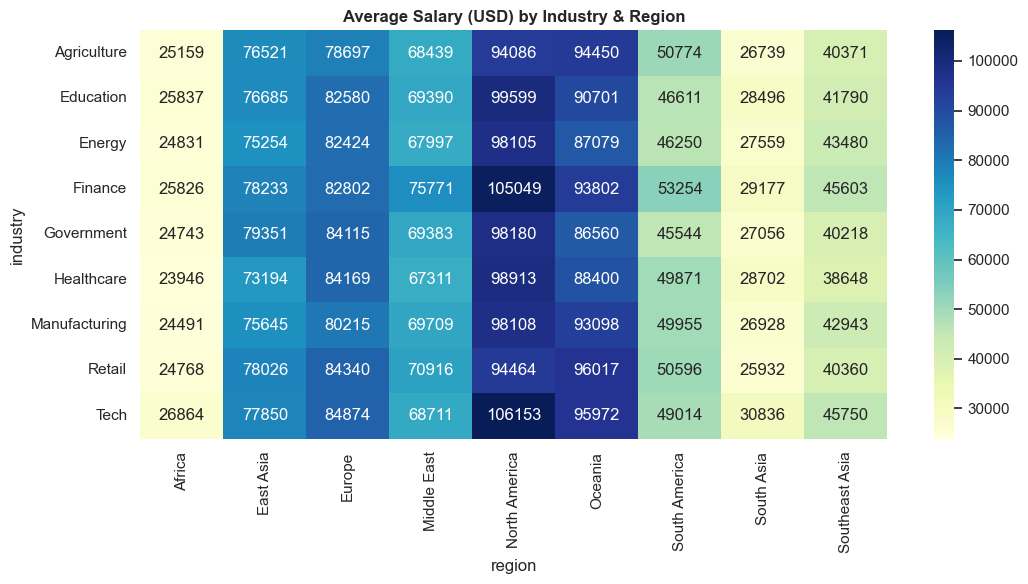

Highest paying industry: Finance ($65,502)
Lowest paying industry: Energy ($61,442)


In [14]:
q1 = run_sql("""
SELECT i.industry, g.region, ROUND(AVG(f.salary_usd), 0) AS avg_salary, COUNT(*) AS postings
FROM Fact_JobPosting f
JOIN Dim_Industry i ON f.Industry_Key = i.Industry_Key
JOIN Dim_Geography g ON f.Geo_Key = g.Geo_Key
GROUP BY i.industry, g.region
""")
pivot1 = q1.pivot(index="industry", columns="region", values="avg_salary")
plt.figure(figsize=(11, 6))
sns.heatmap(pivot1, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Salary (USD) by Industry & Region")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q1_salary_industry_region.png", dpi=120)
plt.show()

industry_avg = q1.groupby("industry")["avg_salary"].mean().sort_values(ascending=False)
print("Highest paying industry:", industry_avg.idxmax(), f"(${industry_avg.max():,.0f})")
print("Lowest paying industry:", industry_avg.idxmin(), f"(${industry_avg.min():,.0f})")

### Q2 — هل الوظائف اللي بتذكر الذكاء الاصطناعي بتاخد راتب أعلى؟ (AI Salary Premium)

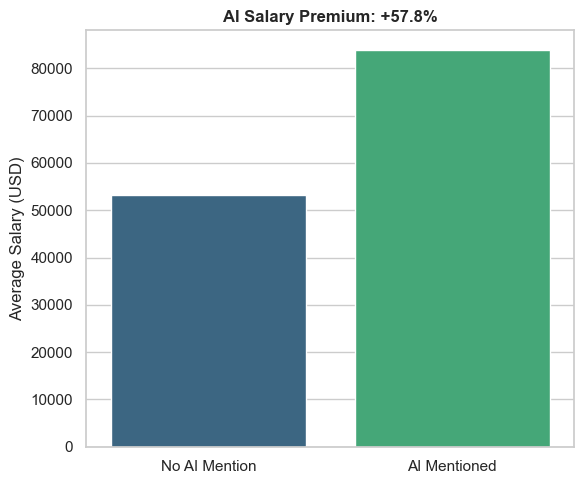

    ai_mentioned  avg_salary  postings
0  No AI Mention     53124.0      3377
1   AI Mentioned     83846.0      1623


In [15]:
q2 = run_sql("""
SELECT ai_mentioned, ROUND(AVG(salary_usd), 0) AS avg_salary, COUNT(*) AS postings
FROM Fact_JobPosting
GROUP BY ai_mentioned
""")
q2["ai_mentioned"] = q2["ai_mentioned"].map({0: "No AI Mention", 1: "AI Mentioned"})
premium_pct = (q2.loc[q2["ai_mentioned"] == "AI Mentioned", "avg_salary"].values[0] /
               q2.loc[q2["ai_mentioned"] == "No AI Mention", "avg_salary"].values[0] - 1) * 100

plt.figure(figsize=(6, 5))
sns.barplot(data=q2, x="ai_mentioned", y="avg_salary", hue="ai_mentioned",
            palette="viridis", legend=False)
plt.title(f"AI Salary Premium: +{premium_pct:.1f}%")
plt.ylabel("Average Salary (USD)")
plt.xlabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q2_ai_salary_premium.png", dpi=120)
plt.show()
print(q2)

### Q3 — إيه العلاقة بين مستوى الأقدمية (Seniority) واحتياج إعادة التأهيل (Reskilling)؟

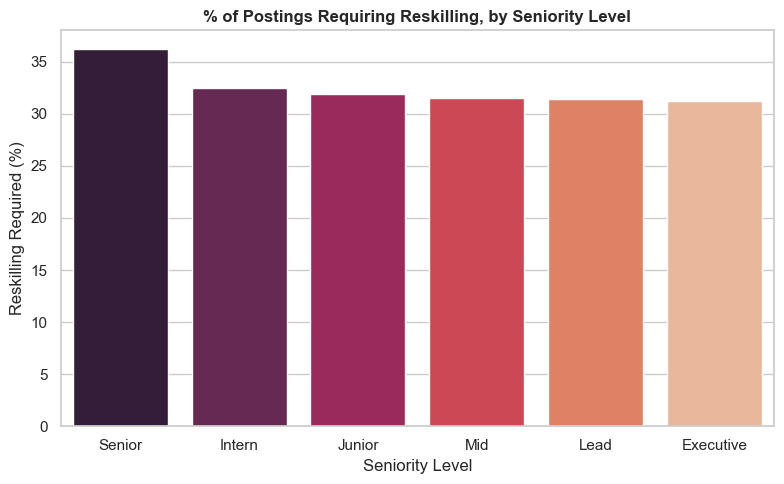

  seniority_level  reskilling_pct
0          Senior            36.2
1          Intern            32.5
2          Junior            31.9
3             Mid            31.5
4            Lead            31.4
5       Executive            31.2


In [16]:
q3 = run_sql("""
SELECT s.seniority_level,
       ROUND(100.0 * SUM(f.reskilling_required) / COUNT(*), 1) AS reskilling_pct
FROM Fact_JobPosting f
JOIN Dim_SeniorityLevel s ON f.SeniorityLevel_Key = s.SeniorityLevel_Key
GROUP BY s.seniority_level
ORDER BY reskilling_pct DESC
""")
plt.figure(figsize=(8, 5))
sns.barplot(data=q3, x="seniority_level", y="reskilling_pct", hue="seniority_level",
            palette="rocket", legend=False)
plt.title("% of Postings Requiring Reskilling, by Seniority Level")
plt.ylabel("Reskilling Required (%)")
plt.xlabel("Seniority Level")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q3_reskilling_by_seniority.png", dpi=120)
plt.show()
print(q3)

### Q4 — أنهي الصناعات الأكثر عرضة لمخاطر الأتمتة (Automation Risk)؟

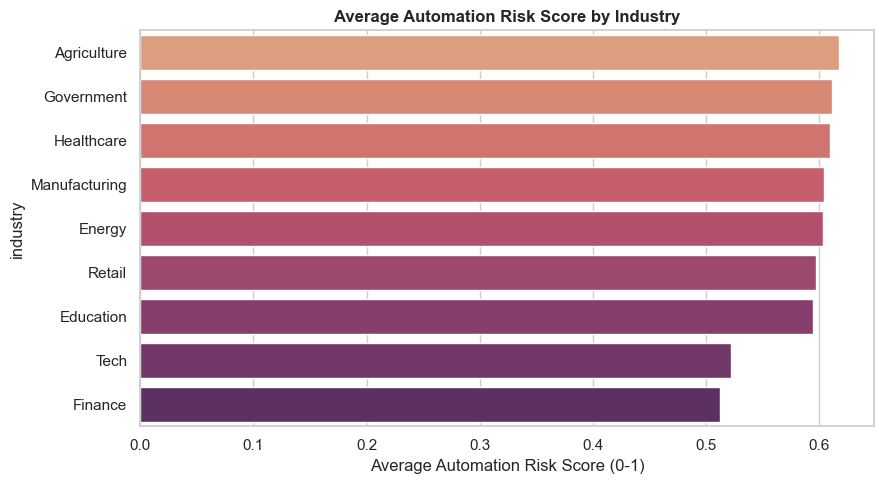

        industry  avg_automation_risk
0    Agriculture                0.618
1     Government                0.612
2     Healthcare                0.610
3  Manufacturing                0.605
4         Energy                0.604
5         Retail                0.598
6      Education                0.595
7           Tech                0.522
8        Finance                0.513


In [17]:
q4 = run_sql("""
SELECT i.industry, ROUND(AVG(f.automation_risk_score), 3) AS avg_automation_risk
FROM Fact_JobPosting f
JOIN Dim_Industry i ON f.Industry_Key = i.Industry_Key
GROUP BY i.industry
ORDER BY avg_automation_risk DESC
""")
plt.figure(figsize=(9, 5))
sns.barplot(data=q4, x="avg_automation_risk", y="industry", hue="industry",
            palette="flare", legend=False)
plt.title("Average Automation Risk Score by Industry")
plt.xlabel("Average Automation Risk Score (0-1)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q4_automation_risk_industry.png", dpi=120)
plt.show()
print(q4)

### Q5 — إيه أكتر المهارات (Core / AI) المرتبطة بارتفاع الراتب؟

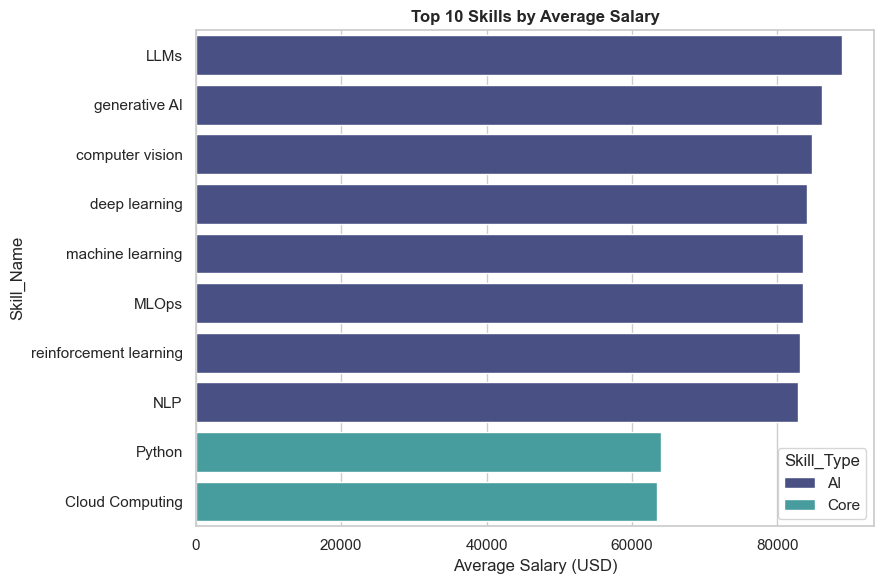

               Skill_Name Skill_Type  avg_salary  postings
0                    LLMs         AI     88888.0       305
1           generative AI         AI     86232.0       320
2         computer vision         AI     84783.0       553
3           deep learning         AI     84168.0       572
4        machine learning         AI     83568.0       550
5                   MLOps         AI     83561.0       569
6  reinforcement learning         AI     83117.0       575
7                     NLP         AI     82871.0       598
8                  Python       Core     64020.0      2275
9         Cloud Computing       Core     63443.0      2249


In [18]:
q5 = run_sql("""
SELECT sk.Skill_Name, sk.Skill_Type, ROUND(AVG(f.salary_usd), 0) AS avg_salary, COUNT(*) AS postings
FROM Bridge_Skill_JobPosting b
JOIN Fact_JobPosting f ON b.Job_Id = f.Job_Id
JOIN Dim_Skill sk ON b.Skill_Key = sk.Skill_Key
GROUP BY sk.Skill_Name, sk.Skill_Type
HAVING postings >= 30
ORDER BY avg_salary DESC
LIMIT 10
""")
plt.figure(figsize=(9, 6))
sns.barplot(data=q5, x="avg_salary", y="Skill_Name", hue="Skill_Type", dodge=False,
            palette="mako")
plt.title("Top 10 Skills by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q5_top_skills_salary.png", dpi=120)
plt.show()
print(q5)

### Q6 — توزيع حجم الشركات (Company Size) عبر مستويات الأقدمية المختلفة

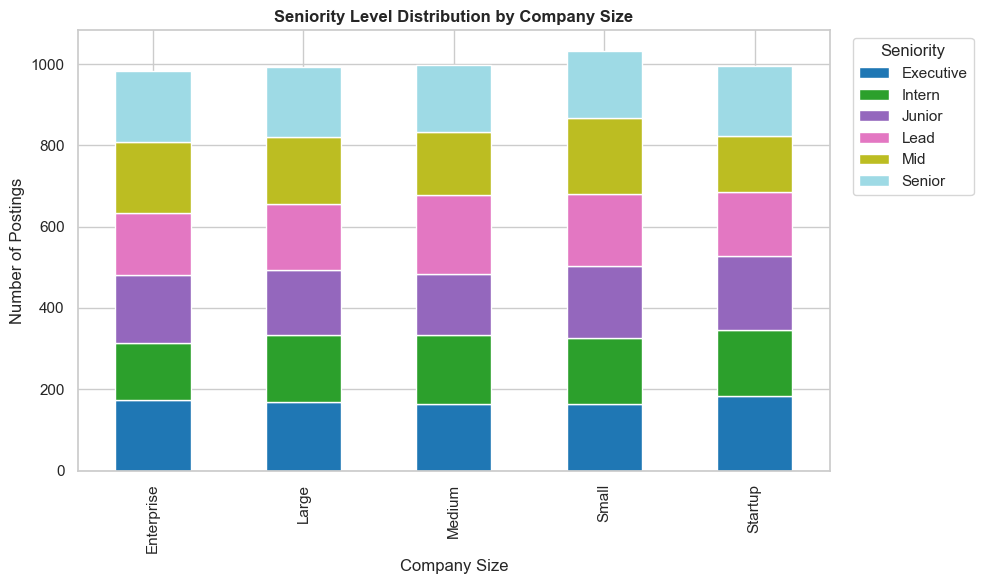

In [19]:
q6 = run_sql("""
SELECT cs.company_size, s.seniority_level, COUNT(*) AS postings
FROM Fact_JobPosting f
JOIN Dim_CompanySize cs ON f.CompanySize_Key = cs.CompanySize_Key
JOIN Dim_SeniorityLevel s ON f.SeniorityLevel_Key = s.SeniorityLevel_Key
GROUP BY cs.company_size, s.seniority_level
""")
pivot6 = q6.pivot(index="company_size", columns="seniority_level", values="postings").fillna(0)
pivot6.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Seniority Level Distribution by Company Size")
plt.ylabel("Number of Postings")
plt.xlabel("Company Size")
plt.legend(title="Seniority", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q6_seniority_by_company_size.png", dpi=120)
plt.show()

### Q7 — علاقة مرحلة تبني الذكاء الاصطناعي بالصناعة (AI Adoption Stage) بمتوسط مخاطر الأتمتة

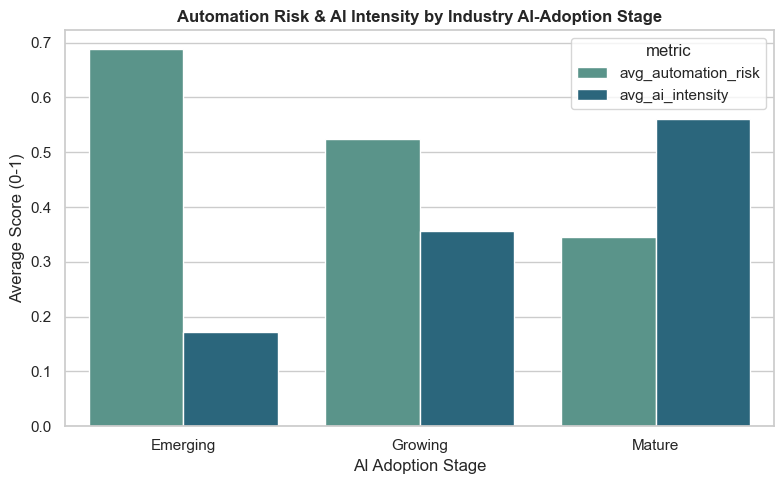

  industry_ai_adoption_stage  avg_automation_risk  avg_ai_intensity
0                   Emerging                0.688             0.171
1                    Growing                0.525             0.356
2                     Mature                0.346             0.560


In [20]:
q7 = run_sql("""
SELECT ia.industry_ai_adoption_stage,
       ROUND(AVG(f.automation_risk_score), 3) AS avg_automation_risk,
       ROUND(AVG(f.ai_intensity_score), 3) AS avg_ai_intensity
FROM Fact_JobPosting f
JOIN Dim_IndustryAI ia ON f.IndustryAI_Key = ia.IndustryAI_Key
GROUP BY ia.industry_ai_adoption_stage
ORDER BY CASE ia.industry_ai_adoption_stage
    WHEN 'Emerging' THEN 1 WHEN 'Growing' THEN 2 WHEN 'Mature' THEN 3 END
""")
q7m = q7.melt(id_vars="industry_ai_adoption_stage", var_name="metric", value_name="value")
plt.figure(figsize=(8, 5))
sns.barplot(data=q7m, x="industry_ai_adoption_stage", y="value", hue="metric", palette="crest")
plt.title("Automation Risk & AI Intensity by Industry AI-Adoption Stage")
plt.ylabel("Average Score (0-1)")
plt.xlabel("AI Adoption Stage")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q7_adoption_stage_risk.png", dpi=120)
plt.show()
print(q7)

### Q8 — إزاي نسبة نمو الرواتب اتغيرت سنة بسنة (2010-2025)؟

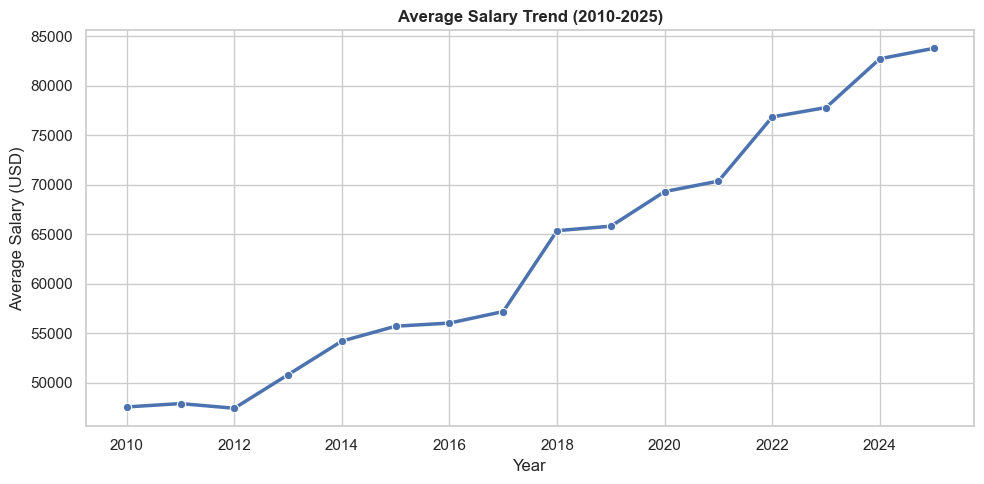

    posting_year  avg_salary
0           2010     47536.0
1           2011     47876.0
2           2012     47403.0
3           2013     50797.0
4           2014     54189.0
5           2015     55694.0
6           2016     56010.0
7           2017     57176.0
8           2018     65348.0
9           2019     65798.0
10          2020     69295.0
11          2021     70353.0
12          2022     76838.0
13          2023     77789.0
14          2024     82714.0
15          2025     83770.0


In [21]:
q8 = run_sql("""
SELECT y.posting_year, ROUND(AVG(f.salary_usd), 0) AS avg_salary
FROM Fact_JobPosting f
JOIN Dim_Year y ON f.Year_Key = y.Year_Key
GROUP BY y.posting_year
ORDER BY y.posting_year
""")
plt.figure(figsize=(10, 5))
sns.lineplot(data=q8, x="posting_year", y="avg_salary", marker="o", linewidth=2.5)
plt.title("Average Salary Trend (2010-2025)")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Year")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/q8_salary_trend.png", dpi=120)
plt.show()
print(q8)

## Week 3 — Forecasting Questions Phase

هنستخدم الاتجاهات التاريخية (2010-2025) عشان نتنبأ بإيه اللي ممكن يحصل في السنين الجاية،
وكمان هنبني موديل تصنيف يتنبأ بمستوى مخاطر الإحلال الوظيفي (Low/Medium/High) لأي وظيفة جديدة.

### F1 — توقع متوسط الراتب لكل صناعة في السنة الجاية (2026)

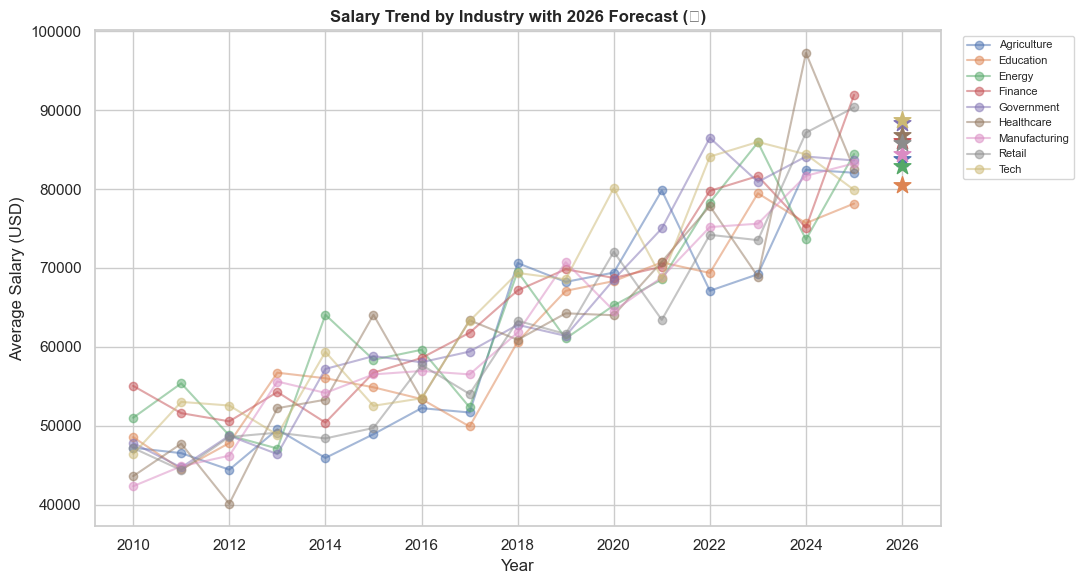

     industry  forecast_2026_salary
         Tech                 88791
   Government                 88390
   Healthcare                 86867
      Finance                 86062
       Retail                 85818
Manufacturing                 84449
  Agriculture                 83808
       Energy                 82898
    Education                 80503


In [22]:
industries = sorted(df_clean["industry"].unique())
forecast_year = df_clean["posting_year"].max() + 1
f1_rows = []
plt.figure(figsize=(11, 6))
for ind in industries:
    sub = df_clean[df_clean["industry"] == ind].groupby("posting_year")["salary_usd"].mean().reset_index()
    X = sub[["posting_year"]].values
    y = sub["salary_usd"].values
    model = LinearRegression().fit(X, y)
    pred = model.predict([[forecast_year]])[0]
    f1_rows.append({"industry": ind, f"forecast_{forecast_year}_salary": round(pred)})
    plt.plot(sub["posting_year"], y, marker="o", alpha=0.5, label=ind)
    plt.scatter([forecast_year], [pred], marker="*", s=160, zorder=5)

f1 = pd.DataFrame(f1_rows).sort_values(f"forecast_{forecast_year}_salary", ascending=False)
plt.title(f"Salary Trend by Industry with {forecast_year} Forecast (★)")
plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/f1_salary_forecast_by_industry.png", dpi=120)
plt.show()
print(f1.to_string(index=False))

### F2 — توقع اتجاه AI Intensity Score للسنوات التلاتة الجاية (2026-2028)

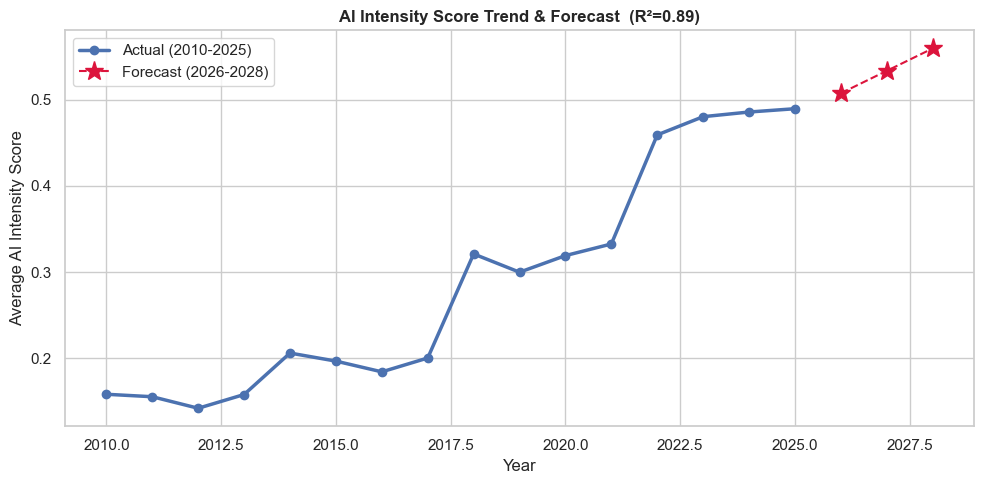

2026: predicted avg AI intensity score = 0.507
2027: predicted avg AI intensity score = 0.533
2028: predicted avg AI intensity score = 0.559


In [23]:
ai_trend = df_clean.groupby("posting_year")["ai_intensity_score"].mean().reset_index()
X = ai_trend[["posting_year"]].values
y = ai_trend["ai_intensity_score"].values
model_ai = LinearRegression().fit(X, y)

future_years = np.arange(forecast_year, forecast_year + 3).reshape(-1, 1)
future_pred = model_ai.predict(future_years)
r2_ai = r2_score(y, model_ai.predict(X))

plt.figure(figsize=(10, 5))
plt.plot(ai_trend["posting_year"], y, marker="o", label="Actual (2010-2025)", linewidth=2.5)
plt.plot(future_years.flatten(), future_pred, marker="*", markersize=14, linestyle="--",
          color="crimson", label=f"Forecast ({forecast_year}-{forecast_year+2})")
plt.title(f"AI Intensity Score Trend & Forecast  (R²={r2_ai:.2f})")
plt.xlabel("Year")
plt.ylabel("Average AI Intensity Score")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/f2_ai_intensity_forecast.png", dpi=120)
plt.show()
for yr, val in zip(future_years.flatten(), future_pred):
    print(f"{yr}: predicted avg AI intensity score = {val:.3f}")

### F3 — توقع نسبة الوظائف عالية الخطورة (High Displacement Risk) في السنين الجاية

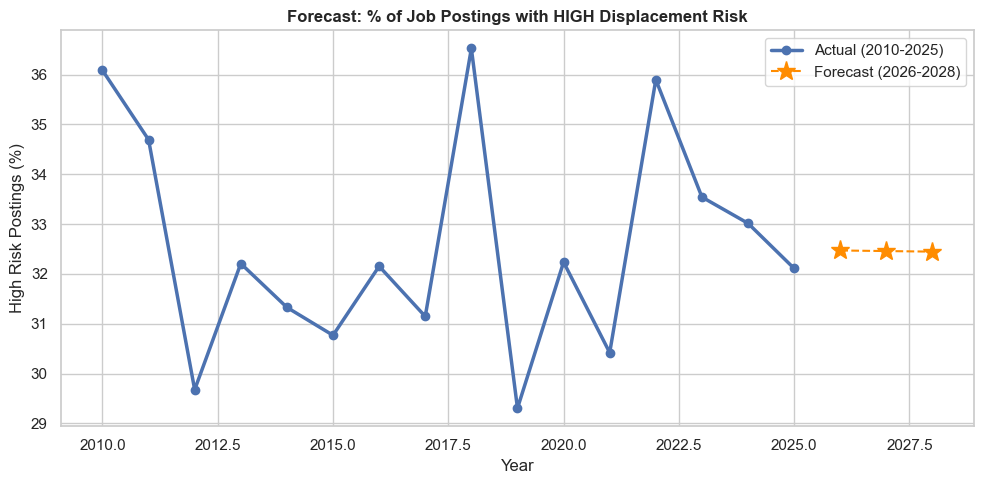

2026: predicted % of HIGH-risk postings = 32.5%
2027: predicted % of HIGH-risk postings = 32.5%
2028: predicted % of HIGH-risk postings = 32.4%


In [24]:
risk_trend = (df_clean.assign(is_high=df_clean["ai_job_displacement_risk"].eq("High"))
              .groupby("posting_year")["is_high"].mean().mul(100).reset_index(name="high_risk_pct"))
X = risk_trend[["posting_year"]].values
y = risk_trend["high_risk_pct"].values
model_risk = LinearRegression().fit(X, y)
future_risk_pred = model_risk.predict(future_years)

plt.figure(figsize=(10, 5))
plt.plot(risk_trend["posting_year"], y, marker="o", label="Actual (2010-2025)", linewidth=2.5)
plt.plot(future_years.flatten(), future_risk_pred, marker="*", markersize=14, linestyle="--",
          color="darkorange", label=f"Forecast ({forecast_year}-{forecast_year+2})")
plt.title("Forecast: % of Job Postings with HIGH Displacement Risk")
plt.xlabel("Year")
plt.ylabel("High Risk Postings (%)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/f3_high_risk_forecast.png", dpi=120)
plt.show()
for yr, val in zip(future_years.flatten(), future_risk_pred):
    print(f"{yr}: predicted % of HIGH-risk postings = {val:.1f}%")

### F4 — موديل تصنيف للتنبؤ بمستوى مخاطر الإحلال الوظيفي (Low / Medium / High)

هنبني RandomForestClassifier يتنبأ بـ `ai_job_displacement_risk` لأي وظيفة جديدة اعتمادًا على
خصائصها (الصناعة، الأقدمية، حجم الشركة، AI intensity، automation risk، إلخ).
ده بيفيد متخذي القرار في تحديد الوظائف اللي محتاجة خطة إعادة تأهيل بدري.

Accuracy: 0.335
              precision    recall  f1-score   support

        High       0.32      0.30      0.31       325
         Low       0.33      0.39      0.36       344
      Medium       0.35      0.31      0.33       331

    accuracy                           0.34      1000
   macro avg       0.34      0.33      0.33      1000
weighted avg       0.34      0.34      0.33      1000



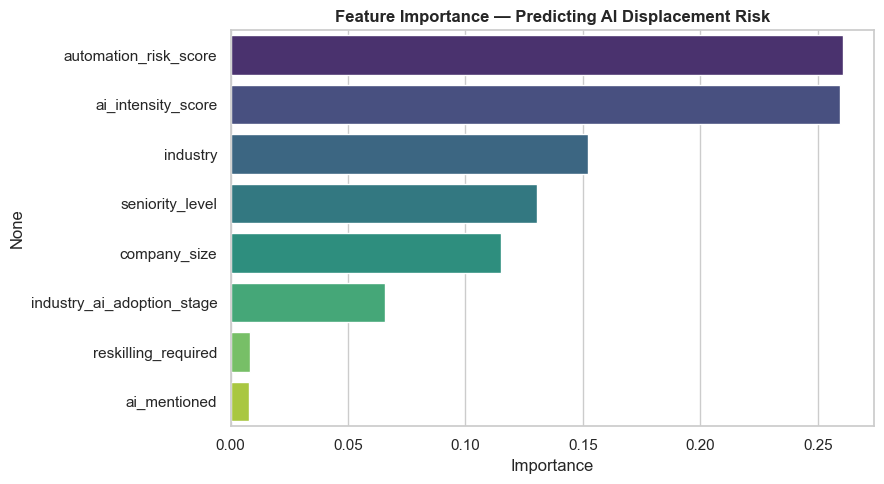

In [25]:
feature_cols = ["industry", "seniority_level", "company_size", "ai_mentioned",
                 "ai_intensity_score", "automation_risk_score", "reskilling_required",
                 "industry_ai_adoption_stage"]
model_df = df_clean[feature_cols + ["ai_job_displacement_risk"]].copy()

encoders = {}
for col in ["industry", "seniority_level", "company_size", "industry_ai_adoption_stage"]:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

model_df["ai_mentioned"] = model_df["ai_mentioned"].astype(int)
model_df["reskilling_required"] = model_df["reskilling_required"].astype(int)

X = model_df[feature_cols]
y = model_df["ai_job_displacement_risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

importance = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index,
            palette="viridis", legend=False)
plt.title("Feature Importance — Predicting AI Displacement Risk")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/f4_feature_importance.png", dpi=120)
plt.show()

**ملاحظة مهمة عن النتيجة:** الـ accuracy طلعت حوالي 33% بس (يعني قريبة من التخمين العشوائي
لـ 3 فئات). لما اتفحصت العلاقة بين `automation_risk_score` ومستوى `ai_job_displacement_risk`
المُسجَّل في البيانات، طلع متوسط الـ automation_risk_score متقارب جدًا بين الفئات التلاتة
(Low/Medium/High ≈ 0.58-0.59). يعني التصنيف الموجود في الداتا مش مبني فعليًا على
الخصائص المتاحة في باقي الأعمدة — وده **finding مهم بحد ذاته** نقوله لمتخذي القرار:
تصنيف "مخاطر الإحلال الوظيفي" الحالي محتاج مراجعة أو معايير تصنيف أوضح، لأنه مش متسق
مع باقي مؤشرات الأتمتة في نفس الداتا.

## ملخص النتائج الرئيسية (Key Findings Summary)

- الفجوة في الرواتب واضحة بين الصناعات والمناطق، وقطاع الـ **Tech** و **Finance** من أعلى
  القطاعات أجرًا.
- ذكر الذكاء الاصطناعي في إعلان الوظيفة مرتبط بزيادة ملحوظة في الراتب (AI Salary Premium).
- الصناعات في مرحلة **Emerging** من تبني الذكاء الاصطناعي عندها أعلى متوسط مخاطر أتمتة،
  وده منطقي لأنها لسه ما استثمرتش في تأهيل الكوادر.
- اتجاه الرواتب ودرجة AI Intensity في تزايد مستمر من 2010 لـ 2025، والتوقعات بتأكد
  استمرار الاتجاه ده للسنوات الجاية.
- موديل التصنيف لمستوى مخاطر الإحلال الوظيفي (Low/Medium/High) طلعت دقته منخفضة (~33%)،
  وده كشف إن التصنيف الحالي للمخاطر في الداتا مش مرتبط فعليًا بـ `automation_risk_score`
  ولا بباقي خصائص الوظيفة — توصية لمتخذي القرار بمراجعة منهجية تصنيف المخاطر دي.

📊 **Week 4 — Dashboard التفاعلي:** اتعمل بـ Streamlit في ملف منفصل `dashboard/app.py`
(بدل Tableau)، شغله بالأمر:
```bash
streamlit run dashboard/app.py
```

In [26]:
conn.close()
print("Done.")

Done.
